Load and Clean Data

In [75]:
#load data zwn
import functions
import pandas as pd
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")

#Clean data
#select useful columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]

#define new columns names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

# convert datatype of "report_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create geometry category and geodataframe
import geopandas as gpd
from shapely.geometry import Point
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns
processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]


# check missing values
#missing_count = processed_zwn[["category","report_time","geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#define missing CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

# load data quartiere
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")
processed_quartiere = raw_quartiere[["qname","geometry"]]
processed_quartiere.head(3)

#define new columns names
new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

# check missing values
#missing_count = processed_quartiere[["Quartier","Geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#transform geometry datatype
#wkt.loads transform string datatype to geometry data type
from shapely import wkt
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

# create geodataframe to interprate "Geometry" as a geometry column
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)

#download processed csv-files
#processed_zwn.to_file("../data/processed/processed_zwn.gpkg", driver="GPKG")
#processed_quartiere.to_file("../data/processed/processed_quartiere.gpkg", driver="GPKG")








Question 1

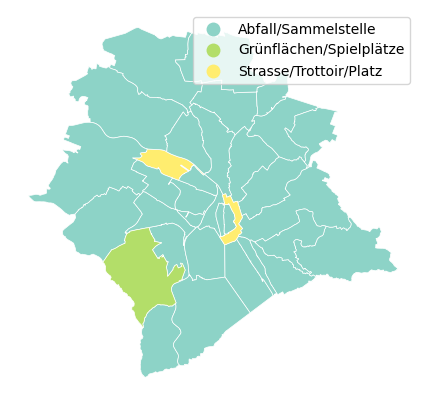

In [73]:
# Question 1: "Welche Problemkategorien werden im jeweiligen statistischen Qaurtier am häufigsten gemeldet?

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")


# Check NaN values in spatial join: 8 NaN values out of 72'411 reports
#zwn_with_quartiere["Quartier"].isna().sum()
#zwn_with_quartiere[zwn_with_quartiere["Quartier"].isna()]
#zwn_with_quartiere["Quartier"].notna().sum()

#count how many times a specific category in a specific quartier is reported
#reset_index wird verwendet, da Output sind Index(also Quartiernamen ist der Index) ist und man will wieder normale Spalten
#name="count" ist der Name der Spalte, sonst wäre er 0

count = zwn_with_quartiere.groupby(["Quartier","category"]).size().reset_index(name="count")
result = count.sort_values(["Quartier", "count"], ascending=[True, False]).drop_duplicates("Quartier")


#plot
import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(result, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert

fig, ax = plt.subplots(figsize=(10,5)) # creates empty figure "Graffiti": "red",

map_df.plot(
    column="category", #each Quartier gets a color based on its category
    categorical=True, # treat values as categories and not numbers
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax #draw the axes on the axes we creaed
)
ax.axis("off")

plt.show()

#fig, ax = plt.subplots(figsize=(10,5))
#processed_quartiere.plot(ax=ax)
#zwn_with_quartiere.plot(ax=ax,color ="lightgrey")

#plt.show()





Question 2

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


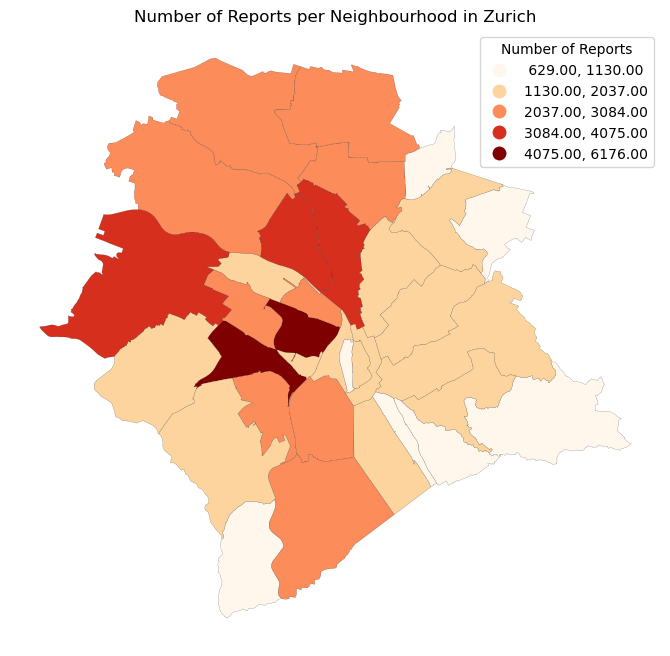

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0, 0.5, 'Frequency')

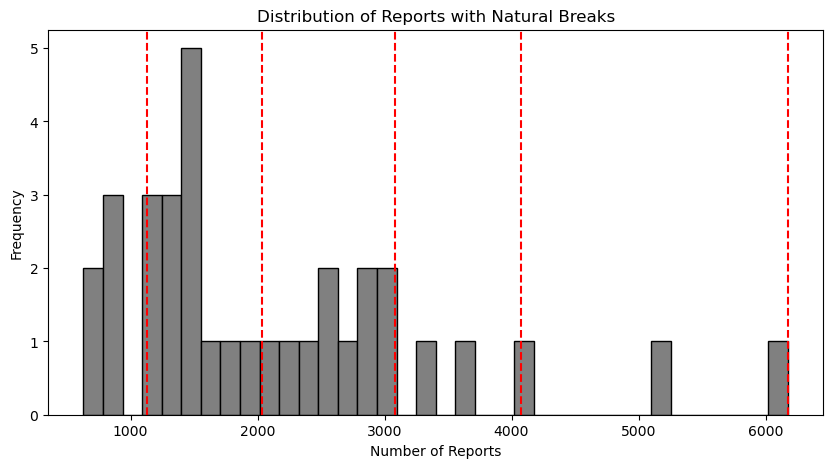

In [79]:
# Question 2: "Which neighbourhood receives the highest number of reports

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#count how many times a report has been submittet in a specific quartier 
count = zwn_with_quartiere.groupby(["Quartier"]).size().reset_index(name="count")



#plot
import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(count, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert
fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


#plot
map_df.plot(
    column="count",
    scheme = "naturalbreaks",
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, #draw the axes on the axes we creaed
      legend_kwds={
        "title": "Number of Reports",
      }
)
ax.set_title("Number of Reports per Neighbourhood in Zurich")

ax.axis("off")



plt.show()
#plt.show()


#fig, ax = plt.subplots(figsize=(10,5))
#processed_quartiere.plot(ax=ax)
#zwn_with_quartiere.plot(ax=ax,color ="lightgrey")

plt.show()

#histogram

import mapclassify

classifier = mapclassify.NaturalBreaks(count["count"],)
breaks = classifier.bins

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(count["count"], bins=36, color= "grey",edgecolor="black")

for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")




Question 3: How do report volumes change overtime per category in Zurich ?

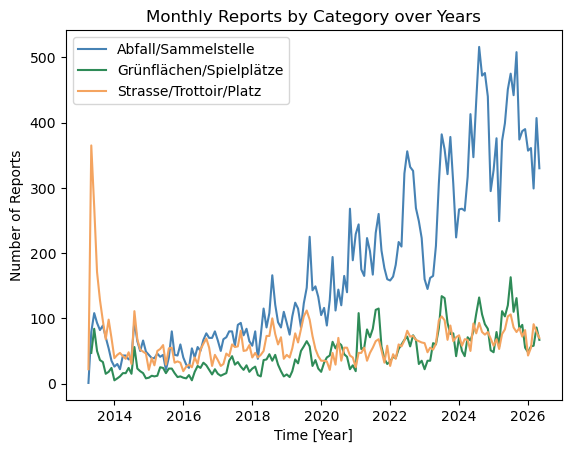

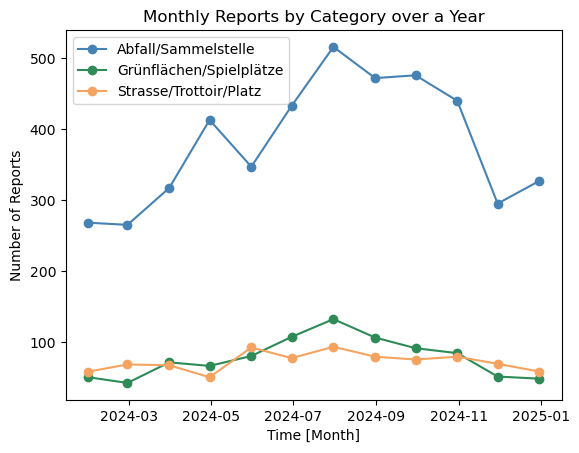

In [87]:
# Question 3: "How do report volumes change overtime in Zurich per category ?"
import functions
#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

plot_category_over_years(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz",])
plot_category_over_a_year(zwn_with_quartiere,["Abfall/Sammelstelle","Grünflächen/Spielplätze","Strasse/Trottoir/Platz",],2024)


Question 4: “How does the processing time vary across neighbourhoods by category in Zurich?”

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


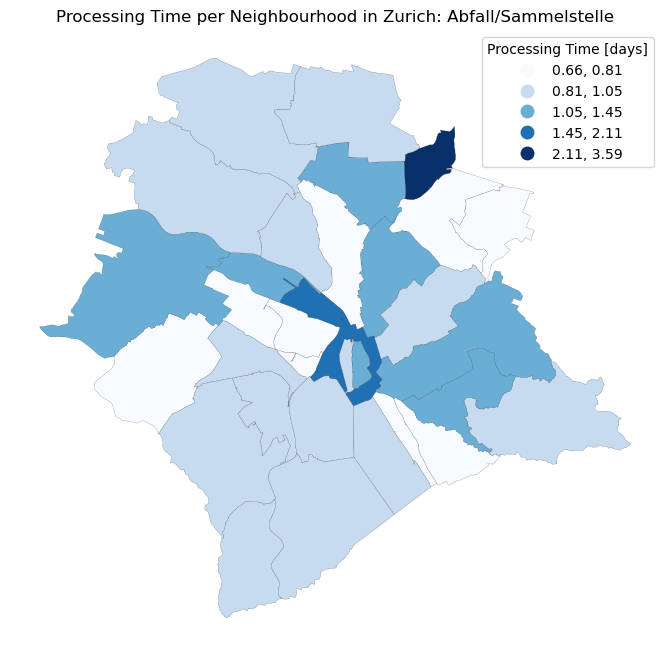

In [85]:
#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#filter data
#filter only reports which are already fixed
zwn_with_quartiere_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]
zwn_with_quartiere_category= zwn_with_quartiere_filtred[zwn_with_quartiere_filtred["category"]=="Abfall/Sammelstelle"]

#calculate processing time
zwn_with_quartiere_category["processing_time"] = zwn_with_quartiere_category["resolved_time"]-zwn_with_quartiere_category["report_time"]


#calculate mean processing time per Quartier
mean = (zwn_with_quartiere_category.groupby(["Quartier"])["processing_time"].mean().reset_index())

#transform timedelta to floatdata in days 
mean["processing_time_float"]= mean["processing_time"].dt.total_seconds()/86400 #86400s = 1 day



#plot
#import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(mean, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert
fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


#plot
map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")

ax.axis("off")

plt.show()

